<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 0: Primeros pasos en la simulación**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 21/08/2026  

---


### **Introducción:**

Para procesar digitalmente cualquier señal de la vida real, el primer paso (y también el más delicado) es la digitalización. Este trabajo lo hace el conversor analógico-digital (ADC), que toma la señal analógica continua $x(t)$ y la traduce en una secuencia discreta de números $x[n]$. Físicamente, este proceso se basa en el muestreo (*sampling*), donde el ADC toma "instantáneas" de la señal en intervalos regulares de tiempo $T_s$ (período de muestreo). Esto significa que nos quedamos únicamente con los valores de la señal en esos instantes específicos, cumpliendo la relación fundamental:

$$x[n] = x(nT_s)$$

La rapidez con la que tomamos estas muestras es la frecuencia de muestreo ($f_s = 1/T_s$). Si queremos asegurar que los datos digitales conserven toda la información de la señal analógica original para poder reconstruirla después de forma idéntica y sin distorsión, tenemos que cumplir estrictamente con el Criterio de Muestreo de Nyquist. Este criterio matemático nos exige que la frecuencia de muestreo sea estrictamente mayor al doble de la componente de frecuencia más alta (ancho de banda) de la señal que estamos midiendo:

$$f_s > 2f_{max}$$

Si muestreamos por debajo de este límite (submuestreo), perdemos información y se produce el fenómeno de aliasing o solapamiento espectral. Lo que ocurre en el dominio de la frecuencia es que el muestreo periódico genera copias infinitas del espectro de la señal repetidas cada $f_s \text{ Hz}$. Al muestrear muy lento, estas copias se superponen y se mezclan. Esto provoca que las frecuencias altas de la señal original "se disfracen" y aparezcan como si fuesen frecuencias bajas en el espectro recuperado. Este error es completamente destructivo e irreversible, ya que una vez que el aliasing ocurre, la fidelidad de la señal se pierde y no hay forma matemática de separar la información mezclada ni de recuperar la forma de onda original.

### **Objetivo y alcance del trabajo:**

Para poner a prueba estos conceptos de forma práctica, el objetivo de este primer Trabajo Semanal (TS0) fue diseñar un generador de señales digital y paramétrico en Python. 

La funcion "mi_funcion_sen" permite configurar de forma directa los parámetros físicos clave de la señal y del ADC: su **amplitud máxima**, **valor medio** (desplazamiento de continua), **frecuencia**, **fase inicial**, la **cantidad de muestras** ($N$) y la **frecuencia de muestreo** ($f_s$).

Finalmente, en la sección **BONUS** se realizo experimentos sistemáticos para ver el aliasing en acción. Se fijo $f_s = 1000 \text{ Hz}$ (dejando el límite de Nyquist en $500 \text{ Hz}$) y se analizo qué sucede al simular frecuencias de **500, 999, 1001 y 2001 Hz**. Este ensayo permitió verificar de manera visual cómo las señales que superan el límite de Nyquist se repliegan en el eje temporal y se "disfrazan" de bajas frecuencias.

### **Codigo completo:**

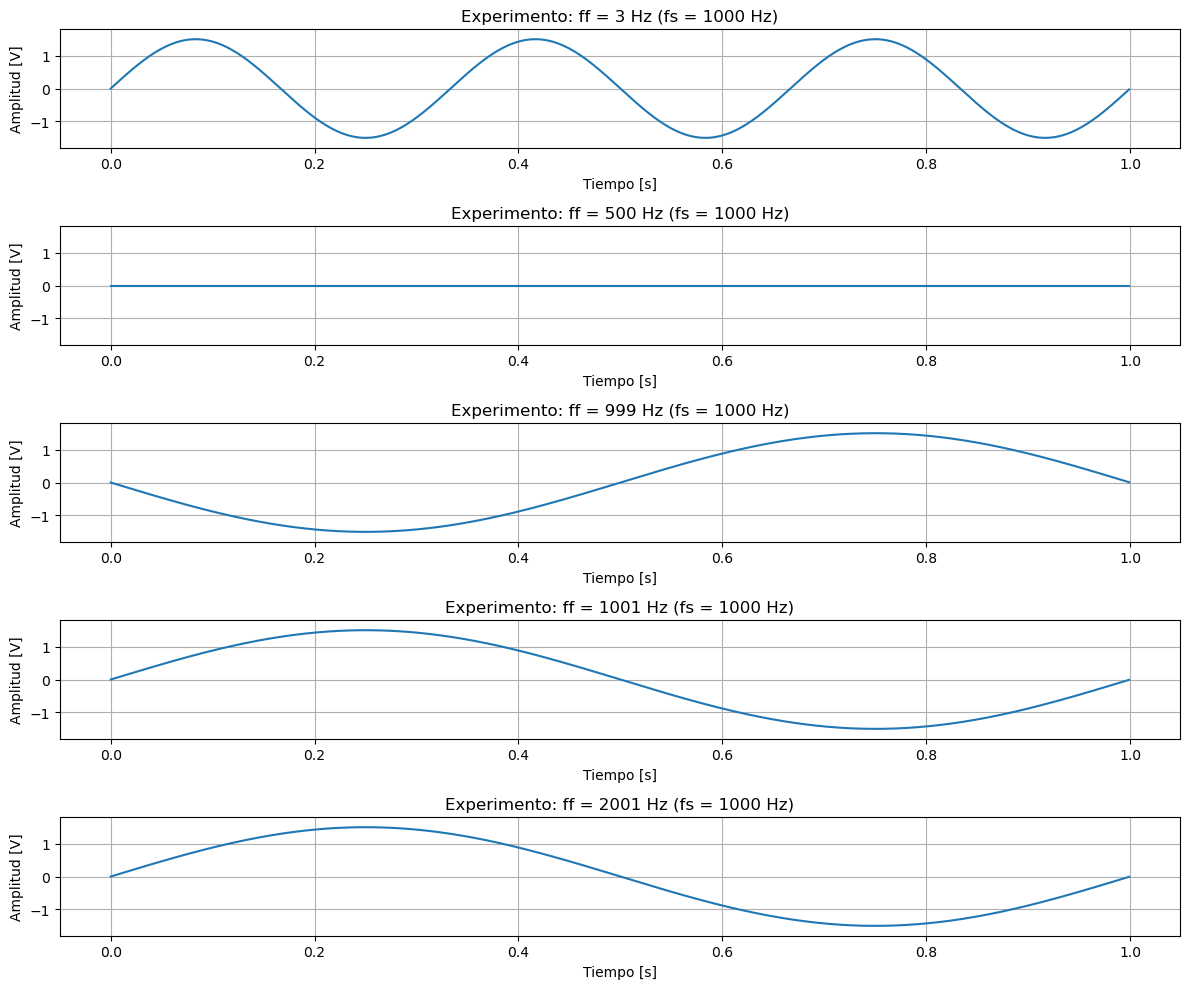

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros globales
fs = 1000  # Frecuencia de muestreo (Hz)
N = 1000   # Cantidad de muestras

# Lista de frecuencias para el experimento (Bonus)
frecuencias = [3, 500, 999, 1001, 2001]

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    ts = 1 / fs
    # Tiempo vector Nx1
    tt = np.arange(nn).reshape(-1, 1) * ts
    # Señal vectorial Nx1
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

# Visualización de los experimentos
plt.figure(figsize=(12, 10))

for i, ff in enumerate(frecuencias):
    tt, xx = mi_funcion_sen(vmax=1.5, dc=0, ff=ff, ph=0, nn=N, fs=fs)
    
    plt.subplot(len(frecuencias), 1, i + 1)
    plt.plot(tt, xx)
    plt.title(f"Experimento: ff = {ff} Hz (fs = {fs} Hz)")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.ylim(-1.8, 1.8)
    plt.grid(True)

plt.tight_layout()
plt.show()

### **Explicacion del codigo:**
```python
import numpy as np
import matplotlib.pyplot as plt

# Parámetros globales
fs = 1000  # Frecuencia de muestreo (Hz)
N = 1000   # Cantidad de muestras

# Lista de frecuencias para el experimento (Bonus)
frecuencias = [3, 500, 999, 1001, 2001]

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    ts = 1 / fs
    # Tiempo vector Nx1
    tt = np.arange(nn).reshape(-1, 1) * ts
    # Señal vectorial Nx1
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx



En el inicio del script, se establecieron las variables que definen el escenario simulado:

* **`fs = 1000`**: Representa la frecuencia de muestreo del ADC en Hertz ($1000 \text{ muestras/s}$), fijando un período de muestreo de $T_s = 1 \text{ ms}$ entre muestras sucesivas. De acuerdo con el teorema de muestreo, esto sitúa la frecuencia de Nyquist (o límite de plegado) exactamente en $500 \text{ Hz}$.
* **`N = 1000`**: Define la cantidad de muestras a registrar. Al tomar $1000 \text{ muestras}$ a una tasa de $1000 \text{ Hz}$, la ventana de observación temporal es de exactamente $1 \text{ segundo}$.
* **`frecuencias`**: Lista que contiene una señal de baja frecuencia ($3 \text{ Hz}$) para validar el código, la frecuencia límite de Nyquist ($500 \text{ Hz}$) y tres casos de submuestreo ($999$, $1001$ y $2001 \text{ Hz}$) para evaluar el fenómeno de aliasing.

La función **`mi_funcion_sen`** se definió con argumentos por defecto (`vmax=1`, `dc=0`, `ff=1`, `ph=0`, `nn=N`, `fs=fs`). Esto permite llamar a la función sin necesidad de especificar todos los parámetros cada vez.

Dentro de la función, se determinó el eje temporal a partir de las siguientes operaciones:

* Se calculó el período de muestreo mediante la inversa de la frecuencia: `ts = 1 / fs`.
* Se generó un arreglo secuencial de índices enteros de muestra ($n = [0, 1, \dots, N-1]$) con `np.arange(nn)`.
* Se utilizó el método `.reshape(-1, 1)` para que se estructurara estrictamente como un vector columna de dimensiones $N \times 1$.
* Se multiplicaron los índices por `ts` para transformar el eje en tiempo físico real en segundos ($t = n T_s$).

La amplitud de la señal se obtuvo mediante la expresión:

`xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc`

Esta línea discretiza la ecuación analógica continua de una sinusoide:

$$x[n] = V_{max} \sin(2\pi f n T_s + \phi) + V_{dc}$$



<br>

### **Análisis de Resultados de los Experimentos**

* **Señal de 3 Hz (Muestreo correcto):** Se observa una onda senoidal limpia y perfectamente definida que completa exactamente 3 ciclos en la ventana de 1 segundo. Al estar muy por debajo del límite de Nyquist ($3 \text{ Hz} \ll 500 \text{ Hz}$), el ADC toma más de 330 muestras por ciclo, capturando la forma de la onda original de manera óptima y sin pérdida de información.

* **Señal de 500 Hz (Frecuencia de Nyquist):** Se observa una línea recta completamente plana en $0 \text{ V}$. Al coincidir de forma exacta con la frecuencia de Nyquist ($f = f_s/2$), el ADC toma muestras periódicas justo en los instantes en que la onda pasa por su cruce por cero. Matemáticamente, la amplitud discreta evaluada resulta en:

$$\sin\left(2\pi \cdot 500 \cdot \frac{n}{1000}\right) = \sin(\pi n) = 0 \quad \forall n \in \mathbb{Z}$$

Esto demuestra de manera empírica por qué el teorema de muestreo exige que $f_s$ sea estrictamente mayor (y no igual) al doble de la frecuencia máxima de la señal.

* **Señal de 999 Hz:** Se observa una onda muy lenta de **1 Hz, pero invertida** (empieza bajando en lugar de subir). Como se superó el límite de $500 \text{ Hz}$, ocurre aliasing. La onda real va casi a la misma velocidad que el ADC, por lo que en cada muestra se la captura un poquito más retrasada, haciendo que parezca una onda de $1 \text{ Hz}$ que gira al revés.

* **Señal de 1001 Hz:** Se observa una onda lenta de **1 Hz normal** (subiendo). Al superar la frecuencia del ADC ($1000 \text{ Hz}$) por apenas $1 \text{ Hz}$, las fotos del muestreo quedan en una posición idéntica a la que tendrían si la señal fuera de $1 \text{ Hz}$ real.

* **Señal de 2001 Hz:** Se observa, otra vez, una onda de **1 Hz normal**. Al ADC le resulta imposible distinguir esta frecuencia tan rápida de la de $1 \text{ Hz}$, porque las muestras caen exactamente en los mismos lugares de la curva.

### **Conclusiones y Aprendizaje**
En este trabajo práctico aprendi a diseñar un generador de señales paramétrico y vectorizado en Python estructurando los datos como vectores columna de $N \times 1$, comprobando de forma experimental que si no se respeta el límite estricto de Nyquist la información se pierde de forma irreversible debido al aliasing, fenómeno por el cual las frecuencias más rápidas se repliegan y terminan disfrazadas en los gráficos como una onda lenta de 1 Hz.